# ZettaiPlot — Quick Start

ZettaiPlot encodes numeric values as **sock coverage height** on stylized anime-aesthetic leg assets.  
The higher the value, the higher the sock is drawn on the leg.

Install:
```bash
pip install zettaiplot
```

In [1]:
import matplotlib.pyplot as plt
import zettaiplot as zp

---
## 1. Single-Series Chart

Pass a plain list (or NumPy array) and optional category labels.

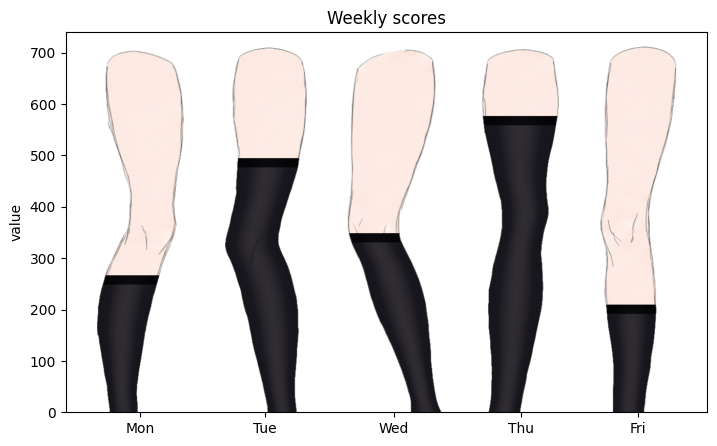

In [2]:
zp.sockbar(
    [42, 78, 55, 91, 33],
    label=["Mon", "Tue", "Wed", "Thu", "Fri"],
)
plt.title("Weekly scores")
plt.tight_layout()
plt.show()

---
## 2. Choosing a Texture

Pass any `SockTextureSpec` to the `texture` parameter.

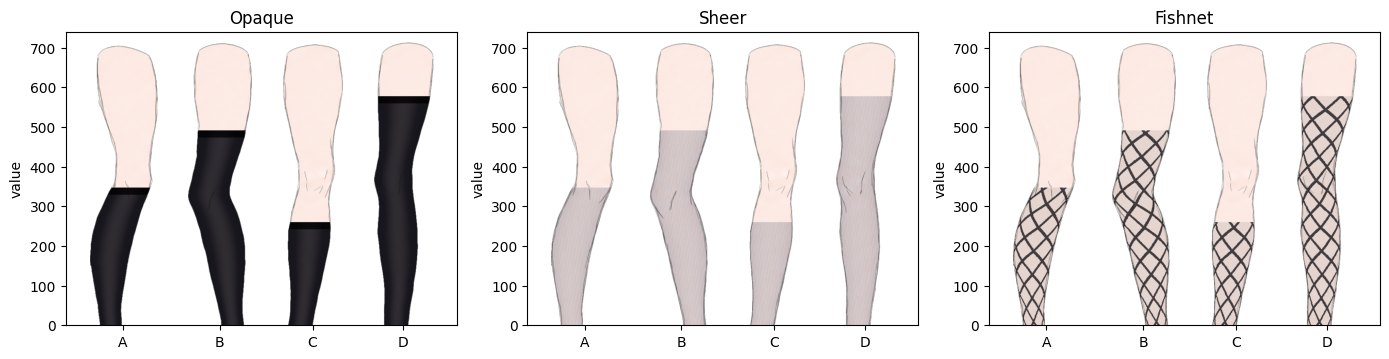

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

textures = [
    ("Opaque",  zp.OpaqueSpec(color="black")),
    ("Sheer",   zp.SheerSpec(color="navy", denier=25)),
    ("Fishnet", zp.FishnetSpec(color="black", cell_size=26)),
]

data  = [60, 85, 45, 100]
label = ["A", "B", "C", "D"]

for ax, (title, spec) in zip(axes, textures):
    zp.sockbar(data, label=label, texture=spec, ax=ax)
    ax.set_title(title)

plt.tight_layout()
plt.show()

---
## 3. All 8 Texture Types

ZettaiPlot ships 8 procedural texture types. Each is a frozen dataclass with independent parameters.

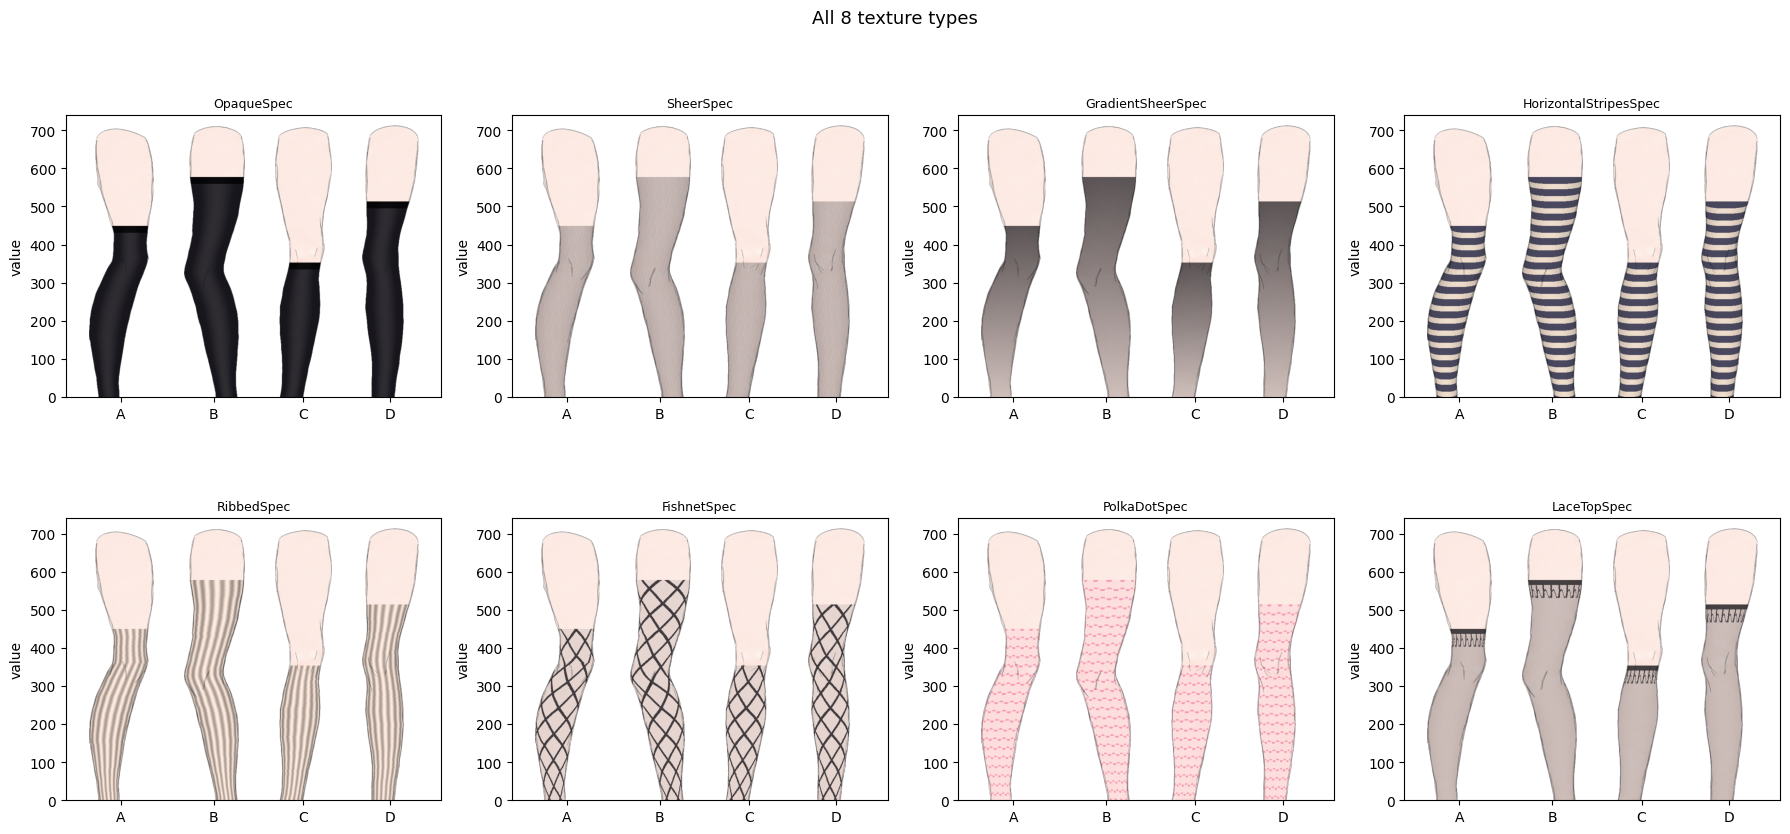

In [4]:
specs = {
    "OpaqueSpec":           zp.OpaqueSpec(color="black"),
    "SheerSpec":            zp.SheerSpec(color="black", denier=40),
    "GradientSheerSpec":    zp.GradientSheerSpec(color="black", top_opacity=0.7, bottom_opacity=0.2),
    "HorizontalStripesSpec": zp.HorizontalStripesSpec(palette=zp.PaletteSpec(preset="school")),
    "RibbedSpec":           zp.RibbedSpec(color="white"),
    "FishnetSpec":          zp.FishnetSpec(color="black"),
    "PolkaDotSpec":         zp.PolkaDotSpec(palette=zp.PaletteSpec(preset="candy")),
    "LaceTopSpec":          zp.LaceTopSpec(base_style="sheer"),
}

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
data  = [70, 90, 55, 80]
label = ["A", "B", "C", "D"]

for ax, (name, spec) in zip(axes.flat, specs.items()):
    zp.sockbar(data, label=label, texture=spec, ax=ax)
    ax.set_title(name, fontsize=9)

plt.suptitle("All 8 texture types", fontsize=13)
plt.tight_layout()
plt.show()

---
## 4. Grouped / Hue Chart

Pass a `dict` where keys are legend labels and values are per-category series.

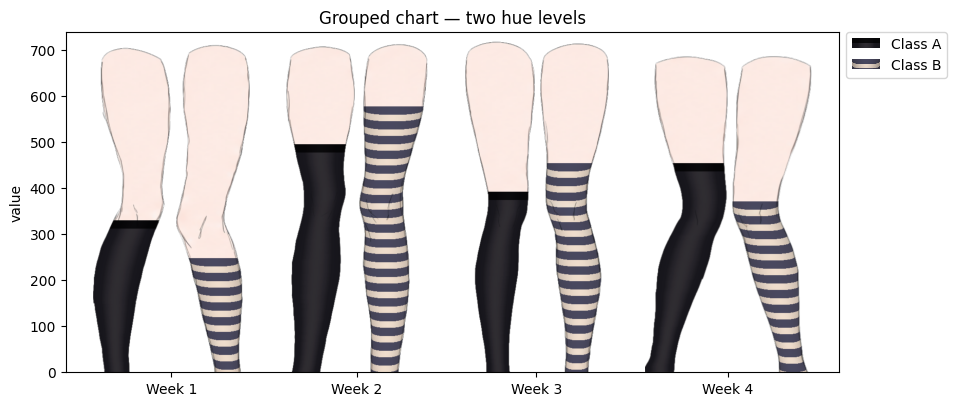

In [5]:
data = {
    "Class A": [80, 120, 95,  110],
    "Class B": [60, 140, 110,  90],
}

zp.sockbar(
    data,
    label=["Week 1", "Week 2", "Week 3", "Week 4"],
    hue_textures={
        "Class A": zp.OpaqueSpec(color="black"),
        "Class B": zp.HorizontalStripesSpec(palette=zp.PaletteSpec(preset="school")),
    },
    legend_kwargs={"loc": "upper left", "bbox_to_anchor": (1.01, 1.0)},
)
plt.title("Grouped chart — two hue levels")
plt.tight_layout()
plt.show()

---
## 5. Custom Colors and Palettes

Colors accept preset strings **or** raw `(r, g, b)` tuples.

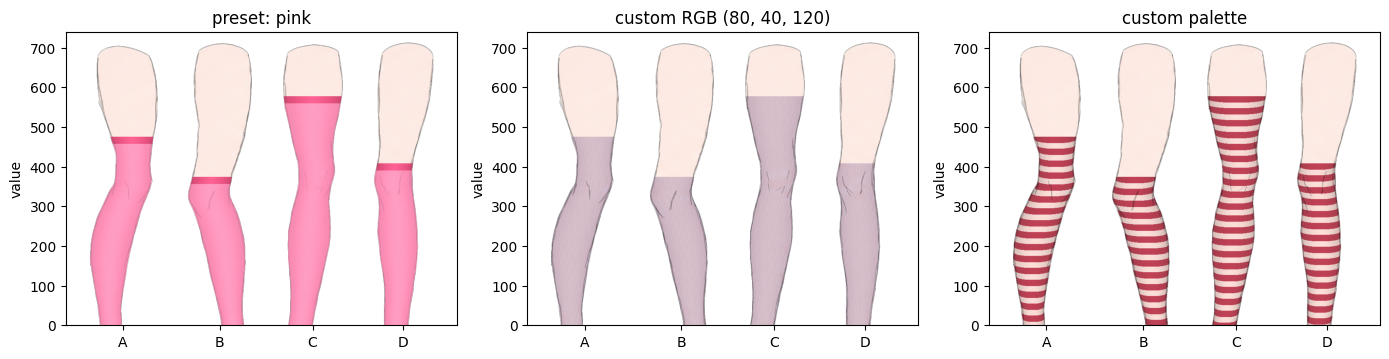

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
data  = [70, 55, 85, 60]
label = ["A", "B", "C", "D"]

# Preset color string
zp.sockbar(data, label=label, texture=zp.OpaqueSpec(color="pink"), ax=axes[0])
axes[0].set_title("preset: pink")

# Custom RGB tuple
zp.sockbar(data, label=label, texture=zp.SheerSpec(color=(80, 40, 120), denier=35), ax=axes[1])
axes[1].set_title("custom RGB (80, 40, 120)")

# Custom two-color palette for stripes
zp.sockbar(
    data, label=label,
    texture=zp.HorizontalStripesSpec(
        palette=zp.PaletteSpec(color_a=(180, 30, 60), color_b=(255, 240, 240)),
        stripe_height=16,
    ),
    ax=axes[2],
)
axes[2].set_title("custom palette")

plt.tight_layout()
plt.show()

---
## 6. Overlapping Legs (Negative `hue_inner_gap`)

Set `hue_inner_gap` to a negative integer to overlap hue legs within a group.

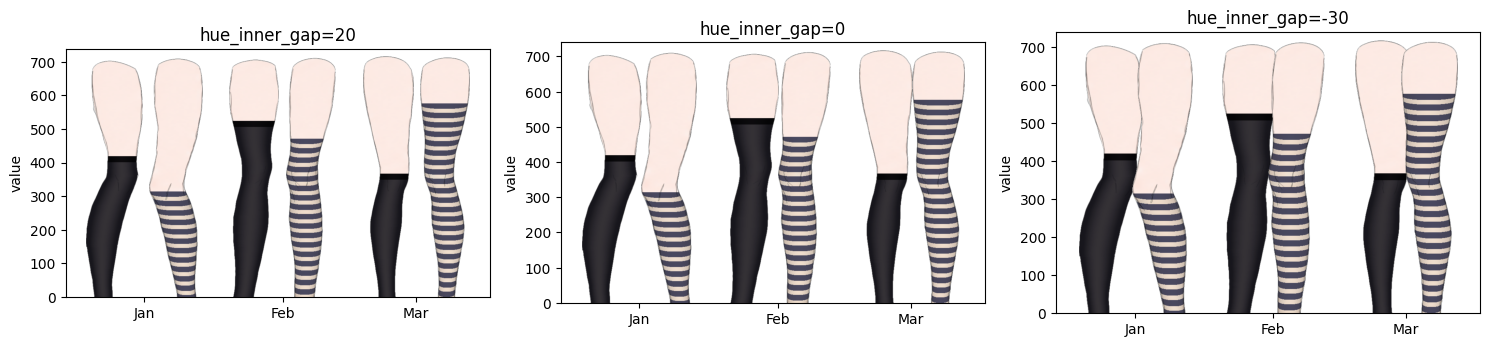

In [7]:
data = {"A": [80, 100, 70], "B": [60, 90, 110]}
label = ["Jan", "Feb", "Mar"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, gap in zip(axes, [20, 0, -30]):
    zp.sockbar(data, label=label, hue_inner_gap=gap, ax=ax, legend=False)
    ax.set_title(f"hue_inner_gap={gap}")

plt.tight_layout()
plt.show()

---
## 7. Plotting into an Existing Figure

Pass an `ax` argument to embed ZettaiPlot inside any existing Matplotlib layout.

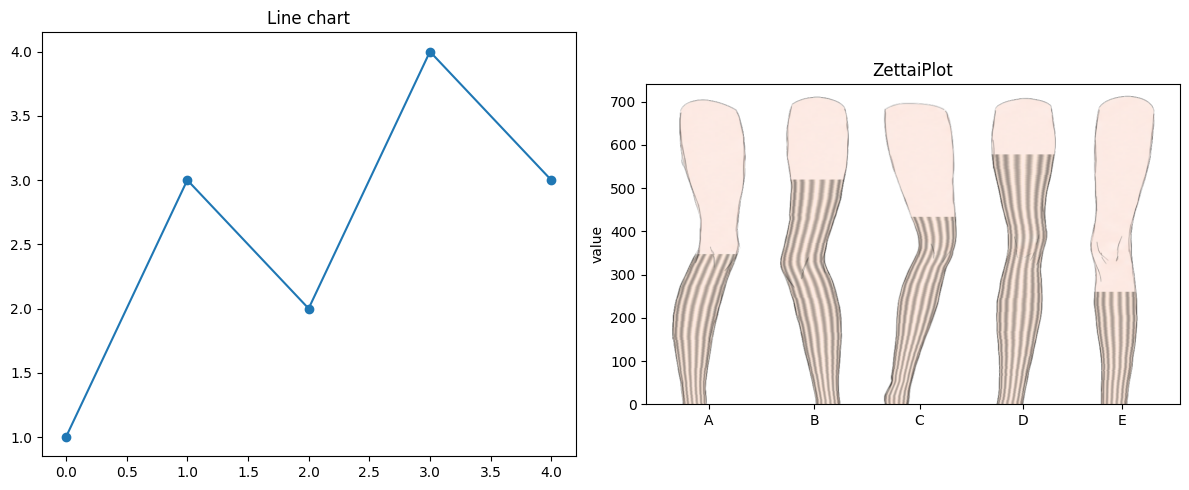

In [8]:
fig, (ax_line, ax_sock) = plt.subplots(1, 2, figsize=(12, 5))

# Regular line chart on the left
ax_line.plot([1, 3, 2, 4, 3], marker="o")
ax_line.set_title("Line chart")

# ZettaiPlot on the right
zp.sockbar(
    [60, 90, 75, 100, 45],
    label=["A", "B", "C", "D", "E"],
    texture=zp.RibbedSpec(color="white"),
    ax=ax_sock,
)
ax_sock.set_title("ZettaiPlot")

plt.tight_layout()
plt.show()

---
## 8. Inspecting the Return Value

`sockbar()` returns a `SockBarContainer` with layout metadata.

In [9]:
import matplotlib
matplotlib.use("Agg")  # headless for non-interactive inspection

container = zp.sockbar(
    [50, 100, 75, 25],
    label=["Q1", "Q2", "Q3", "Q4"],
)

print("Original values:   ", container.values)
print("Normalized values: ", container.normalized_values)
print("Asset IDs:         ", container.asset_ids)
print("Number of artists: ", len(container.image_artists))

placement = container.placements[1]
print(f"\nPlacement[1]: category={placement.category_label!r}, "
      f"x={placement.center_x:.1f}, coverage={placement.coverage_ratio:.3f}")

Original values:    [50.0, 100.0, 75.0, 25.0]
Normalized values:  [0.4, 0.8, 0.6000000000000001, 0.2]
Asset IDs:          ['leg_0_l', 'leg_0_r', 'leg_1_l', 'leg_1_r']
Number of artists:  4

Placement[1]: category='Q2', x=328.5, coverage=0.800


---
## 9. Low-Level: Render a Texture Manually

Use `render_sock_texture()` to apply a texture to a leg image without drawing a chart.

In [12]:
library = zp.load_default_assets()
asset   = library.assets["leg_0_l"]
leg_img = zp.open_leg(asset)

textured = zp.render_sock_texture(
    leg_img,
    zp.PolkaDotSpec(palette=zp.PaletteSpec(preset="candy"), dot_radius=6, dot_spacing=22),
    coverage_ratio=0.70,
)

fig, axes = plt.subplots(1, 2, figsize=(6, 8))
axes[0].imshow(leg_img)
axes[0].set_title("Bare leg")
axes[0].axis("off")
axes[1].imshow(textured)
axes[1].set_title("With polka-dot texture")
axes[1].axis("off")
plt.tight_layout()
plt.show()

/tmp/ipykernel_108068/2305278086.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


---
## Next Steps

- Full parameter reference → [`docs/api.md`](../docs/api.md)
- Texture parameter sweep scripts → [`scripts/`](../scripts/)
- File bugs or requests → [GitHub Issues](https://github.com/xie-huaaaan/ZettaiPlot/issues)